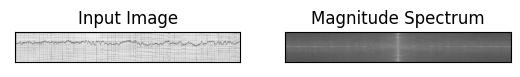

In [4]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Data/Cropped Reports/image1.jpg',0)

# find the discrete fourier transform of the image
dft = cv2.dft(np.float32(img),flags = cv2.DFT_COMPLEX_OUTPUT)

# shift zero-frequency component to the center of the spectrum
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20*np.log(cv2.magnitude(
      dft_shift[:,:,0],
      dft_shift[:,:,1])
   )
# visualize input image and the magnitude spectrum
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

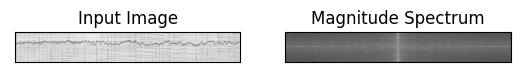

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('Data/Cropped Reports/image1.jpg',0)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift))

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

In [11]:
img = cv2.imread('Data/Cropped Reports/image1.jpg',0)
rows, cols = img.shape
crow,ccol = int(rows/2) ,int (cols/2)

# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols),np.uint8)
mask[crow-60:crow+60, ccol-60:ccol+60] = 1

# apply mask and inverse DFT

f = np.fft.fft2(img)
dft_shift = np.fft.fftshift(f)
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.phase(img_back[:,:,0],img_back[:,:,1])
plt.imsave('Test.jpg',img_back,cmap='gray')
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

error: OpenCV(4.8.1) :-1: error: (-5:Bad argument) in function 'idft'
> Overload resolution failed:
>  - src data type = 15 is not supported
>  - Expected Ptr<cv::UMat> for argument 'src'


'D:\\Desktop\\Education\\NST'

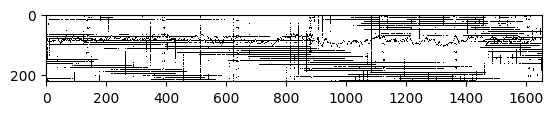

In [35]:
import cv2
import os
image = cv2.imread('Data/Cropped Reports/image1.jpg')
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)


thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Remove horizontal
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100,1))
detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
cnts = cv2.findContours(detected_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(image, [c], -1, (255,255,255), 2)

horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,30))
detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
cnts = cv2.findContours(detected_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(image, [c], -1, (255,255,255), 2)

plt.imsave('Image.jpg',image)
os.getcwd()


In [59]:
from skimage import color
img = color.rgb2gray(plt.imread('Data/Cropped Reports/image1.jpg'))

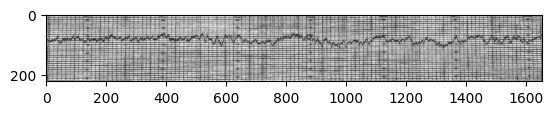

In [61]:

from skimage import exposure

img=exposure.equalize_adapthist(img,clip_limit=0.05)


plt.imshow(img,cmap='gray')
plt.imsave('Test.jpg',img,cmap='gray')

(222, 1653)


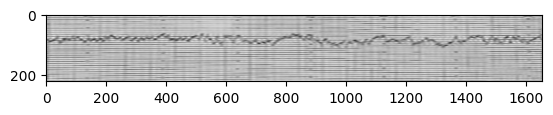

In [65]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

print(img.shape)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift))


rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)

# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols,2),np.uint8)
I=100
mask[crow-I:crow+I, ccol-I:ccol+I] = 1

# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.imshow(img_back,cmap='gray')
plt.imsave('Test.jpg',img_back,cmap='gray')

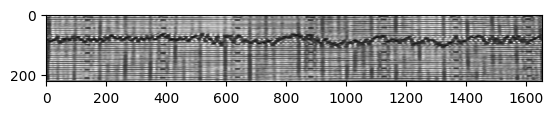

In [92]:
img=exposure.equalize_hist(img_back)


plt.imshow(img,cmap='gray')
plt.imsave('Test.jpg',img,cmap='gray')

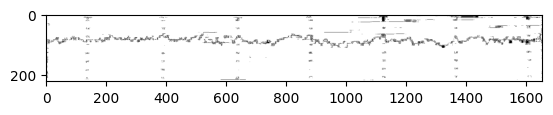

In [128]:
from skimage import util

binary=img<0.25
binary=util.invert(binary)
plt.imshow(binary,cmap='gray')
plt.imsave('2.jpg',binary,cmap='gray')

<__array_function__ internals>:200: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.


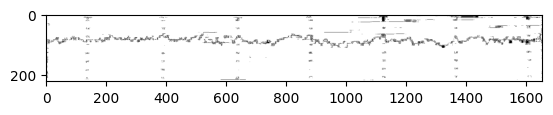

In [129]:
img=exposure.equalize_hist(binary)

plt.imshow(img,cmap='gray')
plt.imsave('Test.jpg',img,cmap='gray')

In [127]:
image = cv2.imread('Test.jpg')
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Remove horizontal
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100,1))
detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
cnts = cv2.findContours(detected_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(image, [c], -1, (255,255,255), 2)

# Repair image
repair_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,6))
result = 255 - cv2.morphologyEx(255 - image, cv2.MORPH_CLOSE, repair_kernel, iterations=1)

plt.imsave('3.jpg',result)

In [126]:
img = cv2.imread('3.jpg',0)

dft = cv2.dft(np.float32(img),flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)

# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols,2),np.uint8)
I=50
mask[crow-I:crow+I, ccol-I:ccol+I] = 1

# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.imsave('4.jpg',img_back,cmap='gray')




Fresh Start

In [396]:
from skimage import color
File_Name='Data/Cropped Reports/image36.jpg'

img = color.rgb2gray(plt.imread(File_Name))

from skimage import exposure

img=exposure.equalize_adapthist(img,clip_limit=0.05)



plt.imsave('0.jpg',img,cmap='gray')

import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('0.jpg',0)

dft = cv2.dft(np.float32(img),flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
#
#
rows, cols = img.shape
crow,ccol = int(rows/2) , int(cols/2)


mask = np.zeros((rows,cols,2),np.uint8)
I=100
mask[crow-I:crow+I, ccol-I:ccol+I] = 1

# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])


plt.imsave('1.jpg',img_back,cmap='gray')
#
img=exposure.equalize_hist(img_back)


plt.imsave('2.jpg',img,cmap='gray')


from skimage import util
img=cv2.imread('2.jpg',0)
binary=img<120
binary=util.invert(binary)

plt.imsave('3.jpg',binary,cmap='gray')

img = plt.imread('3.jpg')
Mean=[]
for h in range(img.shape[1]):
    Test=img[:,h,0]
    T1=np.argwhere(Test<=20).flatten().tolist()
    D=[x+1 for x in np.where(np.diff(T1)!=1)[0]]
    Result=np.split(T1,D)
    Seq=Result[np.argmax([len(X) for X in Result])]
    Mean.append(np.mean(Seq))

IQR=np.percentile(Mean,75)-np.percentile(Mean,25)
Min=np.percentile(Mean,25)-IQR
Max=np.percentile(Mean,75)+IQR


print(Min,Max)

img = color.rgb2gray(plt.imread(File_Name))
plt.imsave('4.jpg',img[int(Min):int(Max),:],cmap='gray')


121.5 138.0


In [378]:
img = plt.imread('3.jpg')
Mean=[]
for h in range(img.shape[1]):
    Test=img[:,h,0]
    T1=np.argwhere(Test<=20).flatten().tolist()
    D=[x+1 for x in np.where(np.diff(T1)!=1)[0]]
    Result=np.split(T1,D)
    Seq=Result[np.argmax([len(X) for X in Result])]
    Mean.append(np.mean(Seq))


(array([ 46.,  32.,  43., 202., 716., 438.,  52.,  37.,  47.,  40.]),
 array([  5. ,  28.9,  52.8,  76.7, 100.6, 124.5, 148.4, 172.3, 196.2,
        220.1, 244. ]),
 <BarContainer object of 10 artists>)

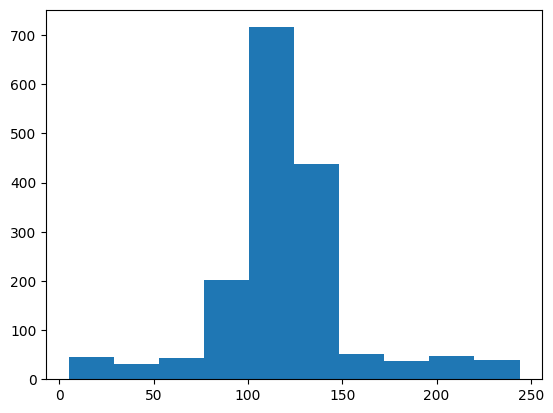

In [379]:
plt.hist(Mean)

In [380]:
IQR=np.percentile(Mean,75)-np.percentile(Mean,25)
Min=np.percentile(Mean,25)-IQR
Max=np.percentile(Mean,75)+IQR
print(Min,Max)
# Filtered_Mean=[x  if( x>Min and x<Max) else np.median(Mean) for x in Mean]

80.5 155.5


In [382]:
img = color.rgb2gray(plt.imread('Data/Cropped Reports/image104.jpg'))
plt.imsave('4.jpg',img[int(Min):int(Max),:],cmap='gray')


In [344]:
list(zip(range(img.shape[1]),Filtered_Mean))

[(0, 84.5),
 (1, 84.5),
 (2, 84.5),
 (3, 84.5),
 (4, 84.5),
 (5, 84.5),
 (6, 84.5),
 (7, 84.5),
 (8, 84.5),
 (9, 58.0),
 (10, 62.5),
 (11, 86.5),
 (12, 84.5),
 (13, 84.5),
 (14, 84.5),
 (15, 89.0),
 (16, 89.0),
 (17, 88.0),
 (18, 89.0),
 (19, 86.5),
 (20, 86.5),
 (21, 86.5),
 (22, 84.5),
 (23, 87.0),
 (24, 86.5),
 (25, 86.5),
 (26, 85.5),
 (27, 87.0),
 (28, 85.5),
 (29, 84.5),
 (30, 84.0),
 (31, 83.0),
 (32, 82.5),
 (33, 83.0),
 (34, 81.0),
 (35, 80.5),
 (36, 79.5),
 (37, 79.5),
 (38, 79.5),
 (39, 79.5),
 (40, 83.5),
 (41, 86.5),
 (42, 91.5),
 (43, 92.0),
 (44, 92.0),
 (45, 92.0),
 (46, 92.0),
 (47, 92.5),
 (48, 92.5),
 (49, 92.5),
 (50, 92.0),
 (51, 93.5),
 (52, 93.5),
 (53, 84.5),
 (54, 84.0),
 (55, 84.0),
 (56, 84.0),
 (57, 84.0),
 (58, 84.5),
 (59, 84.5),
 (60, 85.5),
 (61, 85.5),
 (62, 84.5),
 (63, 85.5),
 (64, 85.5),
 (65, 84.5),
 (66, 83.5),
 (67, 82.5),
 (68, 82.5),
 (69, 80.5),
 (70, 81.0),
 (71, 81.0),
 (72, 82.5),
 (73, 82.5),
 (74, 82.5),
 (75, 83.5),
 (76, 83.5),
 (77, 83.

In [357]:
import pandas as pd
import seaborn as sns

df=pd.DataFrame(dict({'X':range(img.shape[1]),'Y':Filtered_Mean}))
df[df['X']==72]

,X,Y
72,72,82.5
